# 11 · KasPintar: Dari Forecast ke Keputusan (Backtest 23 Minggu)

Simulasi operasional: setiap Minggu malam sistem membuat rekomendasi, Senin pagi ATM diisi, lalu dicek
apakah ATM kehabisan sebelum Senin berikutnya. Periode uji: **Des 1997 – Mei 1998**, termasuk Natal, Tahun Baru,
dan Paskah.

| Kebijakan | Keterangan |
|---|---|
| Aturan praktis | rata-rata 4 minggu terakhir × faktor (1,2 = praktik umum) |
| Seasonal naive | "minggu lalu" + kuantil residual |
| Local | QuantileMLP per bank, tanpa kolaborasi |
| FedAvg | federated, tanpa kalibrasi |
| **KasPintar** | FedAvg + ACI per bank |
| Centralized + ACI | batas atas (data digabung, tidak realistis) |

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob.cash.pipeline import run_atm_case_cached, label
from fedprob.cash.report import (idle_at_same_stockout, plot_cum_fan, plot_tradeoff, tradeoff_curve,
                                 weekly_report, weekly_stockout)
res = run_atm_case_cached(cache_dir="../results", verbose=False)
SYS = res.system
P = ["aturan_praktis", "seasonal_naive", "local", "fedavg", SYS, "central+aci"]

## Hasil backtest pada target service level 95%

In [3]:
bt = pd.DataFrame({label(m): res.backtest(m, level=0.95, factor=1.2) for m in P}).T
bt[["kehabisan_%", "menganggur_%", "isi_rata2", "kurang_rata2"]].style.format("{:.1f}")

,kehabisan_%,menganggur_%,isi_rata2,kurang_rata2
Aturan praktis (rata-rata 4 minggu x faktor),11.4,21.3,161.3,1.6
Seasonal naive + kuantil residual,10.2,22.7,163.4,1.5
Local (tiap bank sendiri),11.0,17.5,156.4,1.3
Federated (FedAvg),11.0,15.2,153.7,1.0
Federated (FedAvg) + ACI,5.4,20.0,160.7,0.5
Centralized (data digabung) + ACI,4.8,20.9,161.8,0.5


- **kehabisan_%**: persentase siklus (ATM × minggu) di mana ATM kosong sebelum pengisian berikutnya. Target ≤ 5%.
- **menganggur_%**: total uang yang tersisa di mesin, relatif terhadap total penarikan.

## Trade-off: kehabisan vs uang menganggur

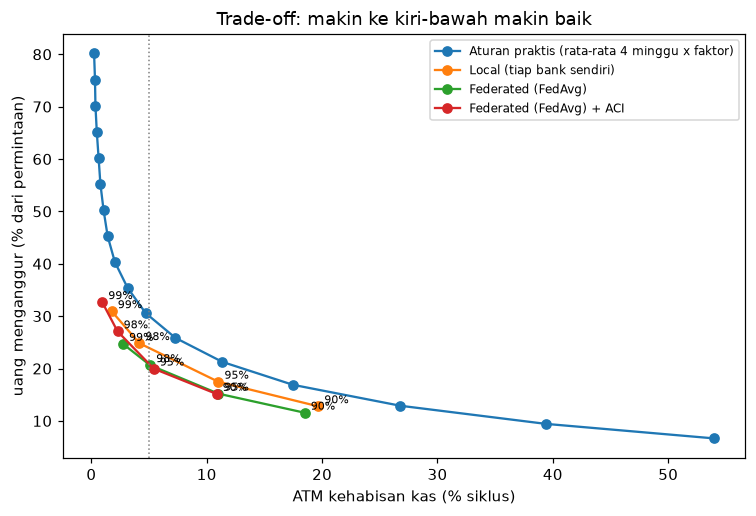

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_tradeoff(res, ["aturan_praktis", "local", "fedavg", SYS], ax=ax)
ax.axvline(5, color="grey", ls=":", lw=1)

In [5]:
cmp = idle_at_same_stockout(res, SYS, 0.95)
print(f"Pada tingkat kehabisan yang sama ({cmp['kehabisan_%']:.1f}%):")
print(f"  aturan praktis butuh faktor ~x{cmp['faktor_aturan_setara']:.2f} dan uang menganggur {cmp['menganggur_aturan_%']:.1f}% dari permintaan")
print(f"  KasPintar: uang menganggur {cmp['menganggur_sistem_%']:.1f}%  ->  hemat {cmp['penghematan_relatif_%']:.0f}% uang menganggur")

Pada tingkat kehabisan yang sama (5.4%):
  aturan praktis butuh faktor ~x1.29 dan uang menganggur 29.3% dari permintaan
  KasPintar: uang menganggur 20.0%  ->  hemat 32% uang menganggur


## Minggu per minggu: apa yang terjadi saat Natal & Paskah?

Text(0.5, 1.0, 'ATM kehabisan per minggu (garis merah: Natal, Jumat Agung)')

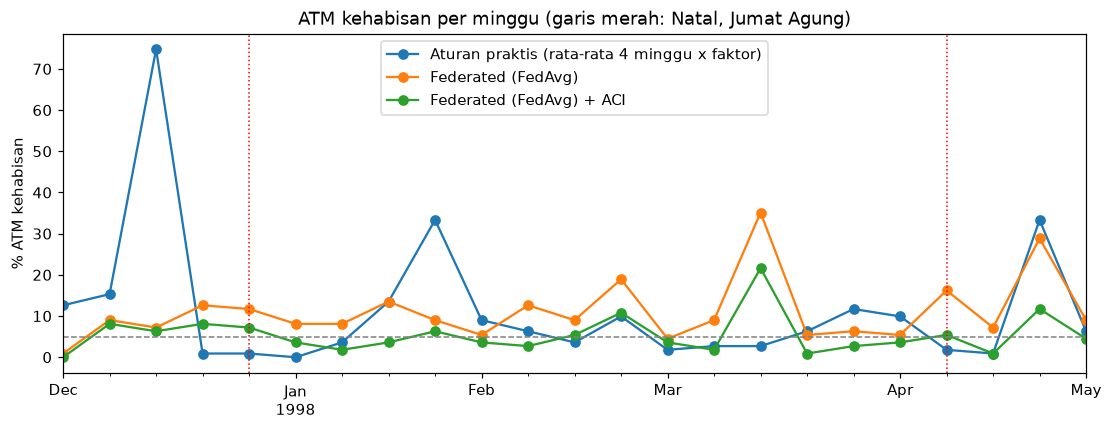

In [6]:
ws = pd.DataFrame({label(m): weekly_stockout(res, m) for m in ["aturan_praktis", "fedavg", SYS]})
ax = ws.plot(marker="o", figsize=(12, 4))
for h in ["1997-12-25", "1998-04-10"]:
    ax.axvline(pd.Timestamp(h), color="red", ls=":", lw=1)
ax.axhline(5, color="grey", ls="--", lw=1); ax.set_ylabel("% ATM kehabisan"); ax.set_title("ATM kehabisan per minggu (garis merah: Natal, Jumat Agung)")

## Bank baru (cold-start): manfaat kolaborasi

In [7]:
rows = []
for b in range(len(res.data.banks)):
    atms = res.data.atms_of(b)
    for m in ["aturan_praktis", "local+aci", SYS]:
        r = res.backtest(m, level=0.95, atms=atms)
        rows.append({"bank": res.bank_name(b), "kebijakan": label(m), "kehabisan_%": r["kehabisan_%"], "menganggur_%": r["menganggur_%"]})
pd.DataFrame(rows).pivot(index="bank", columns="kebijakan").round(1)

kehabisan_%  \
kebijakan    Aturan praktis (rata-rata 4 minggu x faktor)   
bank                                                        
Bank Alfa                                             9.4   
Bank Beta                                            12.6   
Bank Delta                                           10.7   
Bank Epsilon                                         13.0   
Bank Gamma                                           12.0   
Bank Zeta                                            12.0   

                                                                       \
kebijakan    Federated (FedAvg) + ACI Local (tiap bank sendiri) + ACI   
bank                                                                    
Bank Alfa                         5.4                             7.5   
Bank Beta                         5.1                             4.5   
Bank Delta                        6.6                             5.6   
Bank Epsilon                      4.3                             5.3   
Bank Gamma                        5.4                             7.4   
Bank Zeta                         5.4                             3.8   

                                             menganggur_%  \
kebijakan    Aturan praktis (rata-rata 4 minggu x faktor)   
bank                                                        
Bank Alfa                                            20.9   
Bank Beta                                            21.8   
Bank Delta                                           20.7   
Bank Epsilon                                         22.0   
Bank Gamma                                           20.9   
Bank Zeta                                            21.8   

                                                                       
kebijakan    Federated (FedAvg) + ACI Local (tiap bank sendiri) + ACI  
bank                                                                   
Bank Alfa                        19.3                            17.9  
Bank Beta                        19.6                            24.8  
Bank Delta                       19.2                            21.7  
Bank Epsilon                     23.4                            24.0  
Bank Gamma                       19.9                            21.2  
Bank Zeta                        21.3                            56.2

## Laporan Senin untuk operator kas (contoh)

In [8]:
rep = weekly_report(res, bank=5, week=3)
print("Bank Zeta, minggu", rep.attrs["minggu"])
rep.style.format({c: "{:.1f}" for c in rep.columns if rep[c].dtype.kind == "f" and "P(" not in c}).format({"P(habis) jika aturan praktis": "{:.0%}"})

Bank Zeta, minggu 1997-12-22 s/d 1997-12-28


,ATM,perkiraan median,isi rekomendasi,isi aturan praktis,P(habis) jika aturan praktis,aktual 7 hari,habis (rekomendasi),habis (aturan)
1,T27,57.073792,82.146492,66.738946,23%,57.511338,False,False
4,T96,140.822327,195.157959,207.837980,2%,150.460284,False,False
2,T43,134.505493,184.069824,201.972789,2%,135.770975,False,False
3,T64,70.623535,101.917244,121.400579,1%,67.885324,False,False
0,T5,133.275696,176.712173,205.335884,0%,139.455782,False,False
5,T102,153.884247,195.665421,294.481293,0%,201.842404,True,False
6,T104,150.445557,191.001663,248.031463,0%,218.735828,True,False
7,T107,115.898911,160.329956,199.234694,0%,132.780612,False,False


Kolom **P(habis) jika aturan praktis** menunjukkan ATM mana yang berisiko bila bank tetap memakai cara lama.
Kolom *aktual* hanya ada di backtest; dalam operasi nyata, operator hanya melihat rekomendasi dan peluangnya.

## Ilustrasi biaya (asumsi bisa diubah)

In [9]:
from fedprob.cash.policy import total_cost
for cof, pen in [(0.15, 30), (0.15, 60), (0.30, 30)]:
    c = {label(m): total_cost(res.backtest(m, 0.95), cof, pen) for m in ["aturan_praktis", "local", SYS]}
    print(f"biaya simpan {cof:.0%}/thn, penalti kehabisan {pen} unit:", {k: round(v, 2) for k, v in c.items()})

biaya simpan 15%/thn, penalti kehabisan 30 unit: {'Aturan praktis (rata-rata 4 minggu x faktor)': np.float64(3.49), 'Local (tiap bank sendiri)': np.float64(3.37), 'Federated (FedAvg) + ACI': np.float64(1.7)}


biaya simpan 15%/thn, penalti kehabisan 60 unit: {'Aturan praktis (rata-rata 4 minggu x faktor)': np.float64(6.9), 'Local (tiap bank sendiri)': np.float64(6.67), 'Federated (FedAvg) + ACI': np.float64(3.32)}


biaya simpan 30%/thn, penalti kehabisan 30 unit: {'Aturan praktis (rata-rata 4 minggu x faktor)': np.float64(3.57), 'Local (tiap bank sendiri)': np.float64(3.44), 'Federated (FedAvg) + ACI': np.float64(1.78)}


## Kesimpulan studi kasus
*(Angka pasti lihat tabel di atas dan `PROGRESS.md`.)*

1. **KasPintar menepati janjinya.** Pada target 95%, tingkat kehabisan mendekati 5%, termasuk melewati Natal dan
   Paskah, berkat ACI per bank. Model tanpa kalibrasi dan aturan praktis kehabisan ~2× lebih sering.
2. **Lebih efisien.** Pada tingkat kehabisan yang sama, uang menganggur jauh lebih kecil dibanding aturan praktis.
3. **Kolaborasi paling menolong bank baru.** ATM bank Zeta (histori 12 minggu) jauh lebih jarang kehabisan
   dibanding bila bank itu memodelkan sendiri.
4. **Pelajaran metodologis:** (a) model terbaik di simulasi (FedProx) bukan yang terbaik di data riil (FedAvg), sehingga
   seleksi harus berbasis validasi; (b) kalibrasi per ATM gagal karena sampel kecil, sedangkan per bank berhasil.

**Keterbatasan:** data ATM Inggris 1996–1998 (bukan Indonesia), pembagian ke bank bersifat fiktif, satuan nilai
tidak diketahui, satu siklus pengisian tetap (mingguan), dan backtest bukan uji coba operasional.